<a href="https://colab.research.google.com/github/Rodrigoldarocha/analise_exploratoria_vendas_superstore/blob/main/An%C3%A1lise_Explorat%C3%B3ria_de_Vendas_%E2%80%94_Superstore_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análise Exploratória de Vendas — Superstore Sales

## 🎯 Objetivo
Neste projeto, eu realizo uma **Análise Exploratória de Dados (EDA)** utilizando
um dataset público de vendas.

O objetivo é entender melhor os dados e responder perguntas como:
- Quais categorias vendem mais?
- Quais regiões geram mais vendas?
- Como as vendas evoluem ao longo do tempo?

Este projeto foi desenvolvido com foco em **aprendizado prático**
em Ciência de Dados, utilizando Python e bibliotecas amplamente usadas no mercado.


In [49]:
# pandas será utilizado para manipulação e análise dos dados
import pandas as pd

# matplotlib e seaborn serão usados para criar gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# kagglehub permite carregar datasets do Kaggle diretamente
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [50]:
# Defino o nome do arquivo que existe dentro do dataset do Kaggle
file_path = "train.csv"

# Aqui eu carrego o dataset diretamente do Kaggle
# e já o transformo em um DataFrame do pandas
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "rohitsahoo/sales-forecasting",
    file_path
)

# Verifico o tamanho do dataset (linhas e colunas)
print("Dimensão do dataset:", df.shape)

# Visualizo as primeiras linhas para entender a estrutura
df.head()


/tmp/ipython-input-3904240964.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sales-forecasting' dataset.
Dimensão do dataset: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [51]:
# Uso o info() para entender:
# - tipos de dados
# - colunas existentes
# - presença de valores nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [52]:
# Converto as colunas de data de texto para o formato datetime
# Isso é essencial para análises temporais
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [53]:
# Converte colunas de texto para o formato datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [54]:
# Crio uma coluna com o ano do pedido
df['Order Year'] = df['Order Date'].dt.year

# Crio uma coluna com o mês do pedido
df['Order Month'] = df['Order Date'].dt.month


In [55]:
# Agrupo os dados por categoria e somo o valor das vendas
sales_by_category = df.groupby('Category')['Sales'].sum()

# Exibo o resultado
sales_by_category


,Sales
Category,
Furniture,728658.5757
Office Supplies,705422.3340
Technology,827455.8730


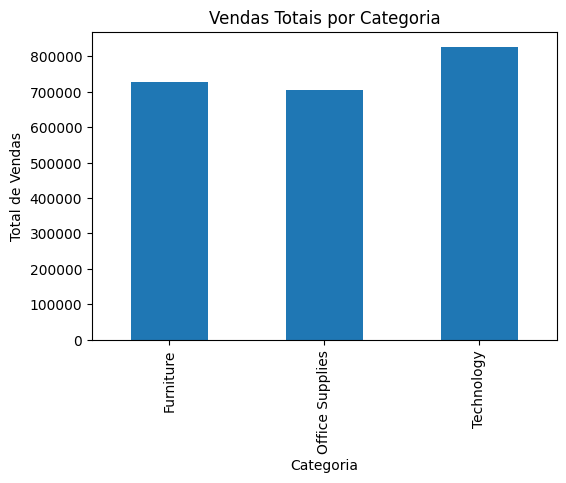

In [56]:
# Crio um gráfico de barras para visualizar melhor
sales_by_category.plot(
    kind='bar',
    figsize=(6,4),
    title='Vendas Totais por Categoria'
)

plt.xlabel('Categoria')
plt.ylabel('Total de Vendas')
plt.show()


In [57]:
# Agrupo as vendas por região
sales_by_region = df.groupby('Region')['Sales'].sum()

sales_by_region


,Sales
Region,
Central,492646.9132
East,669518.7260
South,389151.4590
West,710219.6845


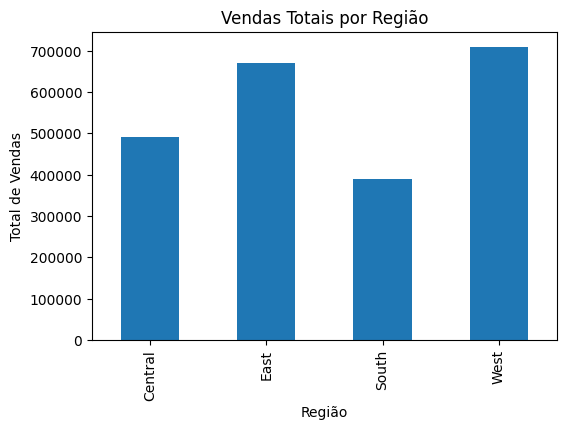

In [58]:
# Visualizo as vendas por região em um gráfico
sales_by_region.plot(
    kind='bar',
    figsize=(6,4),
    title='Vendas Totais por Região'
)

plt.xlabel('Região')
plt.ylabel('Total de Vendas')
plt.show()


In [59]:
# Agrupo as vendas por data do pedido
sales_over_time = df.groupby('Order Date')['Sales'].sum()


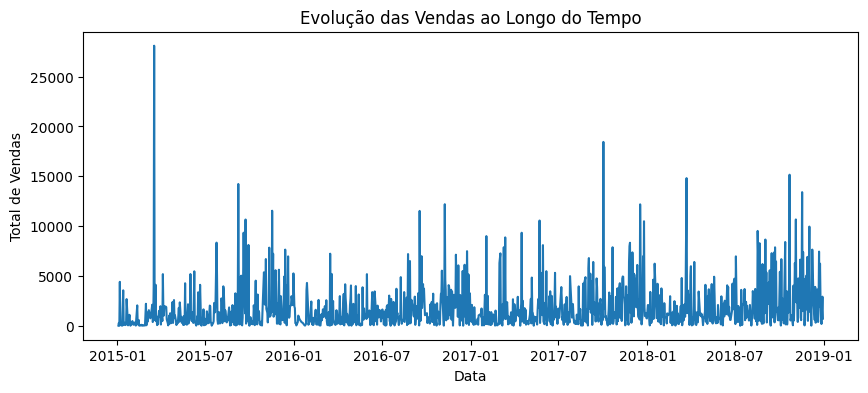

In [60]:
# Crio um gráfico de linha para analisar a evolução das vendas
plt.figure(figsize=(10,4))
plt.plot(sales_over_time)

plt.title('Evolução das Vendas ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Total de Vendas')

plt.show()


In [61]:
# Identifico as 10 subcategorias com maior volume de vendas
top_subcategories = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_subcategories


,Sales
Sub-Category,
Phones,327782.4480
Chairs,322822.7310
Storage,219343.3920
Tables,202810.6280
Binders,200028.7850
Machines,189238.6310
Accessories,164186.7000
Copiers,146248.0940
Bookcases,113813.1987


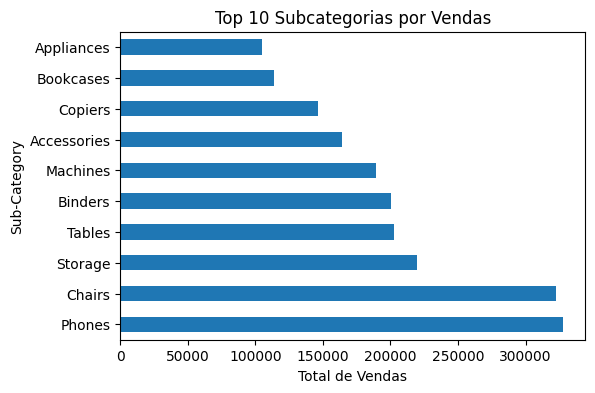

In [62]:
# Gráfico horizontal para facilitar a leitura
top_subcategories.plot(
    kind='barh',
    figsize=(6,4),
    title='Top 10 Subcategorias por Vendas'
)

plt.xlabel('Total de Vendas')
plt.show()


In [63]:
# Identifico a categoria com maior volume de vendas
print("Categoria com maior volume de vendas:")
print(sales_by_category.idxmax())


Categoria com maior volume de vendas:
Technology


In [64]:
# Identifico a região com maior volume de vendas
print("Região com maior volume de vendas:")
print(sales_by_region.idxmax())


Região com maior volume de vendas:
West


In [65]:
# Calculo o ticket médio por segmento de cliente
df.groupby('Segment')['Sales'].mean()


,Sales
Segment,
Consumer,225.065777
Corporate,233.150720
Home Office,243.403309


## ✅ Conclusão

Neste projeto, foi possível:

- Carregar dados diretamente do Kaggle no Google Colab
- Realizar limpeza e preparação básica dos dados
- Executar uma Análise Exploratória de Dados (EDA)
- Criar gráficos para apoiar decisões de negócio
- Extrair insights iniciais sobre vendas

